#A) Create a .csv file out of the given data and put it online (you will use a link to it in your program).

#Data preparation

In [193]:
import numpy as np
import pandas as pd
'''
# Данные
data = {
    "Year": [1959, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970,
             1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982,
             1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994,
             1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003],
    "Average CO2 Concentration (ppmv)": [316.00, 316.91, 317.63, 318.46, 319.02, 319.52,
                                          320.09, 321.34, 322.13, 323.11, 324.60, 325.65,
                                          326.32, 327.52, 329.61, 330.29, 331.16, 332.18,
                                          333.88, 335.52, 336.89, 338.67, 339.95, 341.09,
                                          342.75, 344.44, 345.86, 347.14, 348.99, 351.44,
                                          352.94, 354.19, 355.62, 356.36, 357.10, 358.86,
                                          360.90, 362.58, 363.84, 366.58, 368.30, 369.47,
                                          371.03, 373.07, 375.61]
}

# Создание DataFrame
df = pd.DataFrame(data)

np_array = df.to_numpy()

print(df.shape)


df.to_csv('co2_data.csv', index=False)
'''

csv_url = 'https://drive.google.com/uc?export=download&id=1H1z6_cFrQVeJVBPmp12nTOtFAVxv3gsE'
df = pd.read_csv(csv_url)
print(df.head())

   Year  Average CO2 Concentration (ppmv)
0  1959                            316.00
1  1960                            316.91
2  1961                            317.63
3  1962                            318.46
4  1963                            319.02


#B) Plot the data.

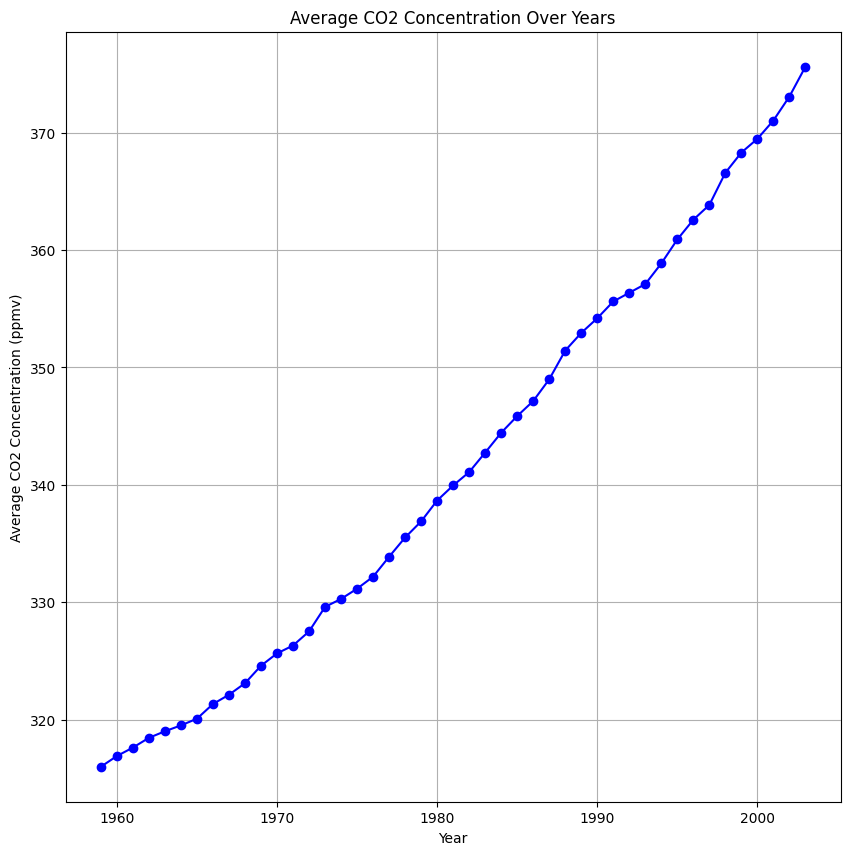

In [194]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
plt.plot(df['Year'], df['Average CO2 Concentration (ppmv)'], marker='o', linestyle='-', color='b')


plt.title('Average CO2 Concentration Over Years')
plt.xlabel('Year')
plt.ylabel('Average CO2 Concentration (ppmv)')

#cетка
plt.grid(True)


plt.show()

#C) Run the ADF test and check if the process is stationary. If not, apply differencing.

I will use Augmented Dickey–Fuller (ADF) Test to check if the data is stationary.

The null hypothesis: there is a unit root present in a
time series.

The augmented Dickey-Fuller (ADF)
test helps us determine if a time
series is stationary by testing for the
presence of a unit root.
If a unit root is present, the time
series is not stationary.

In [195]:
from statsmodels.tsa.stattools import adfuller


ADF_result = adfuller(df['Average CO2 Concentration (ppmv)'])
print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')



ADF Statistic: 3.816548025237233
p-value: 1.0


An ADF statistic of 2.316544104902997 and a p-value of
0.9989654538596132. The ADF statistic is not negative number,
and with a p-value greater than 0.05, we can not
reject the null hypothesis.the series is not
stationary.

Conclusion: the dataset is **not** stationary.

#Differencing

#Data Transformation

ADF Statistic: -3.3237545218120323
p-value: 0.01384946754947721
The series is now stationary!
We can reject the null hypothesis (the series is stationary)!
(44,)


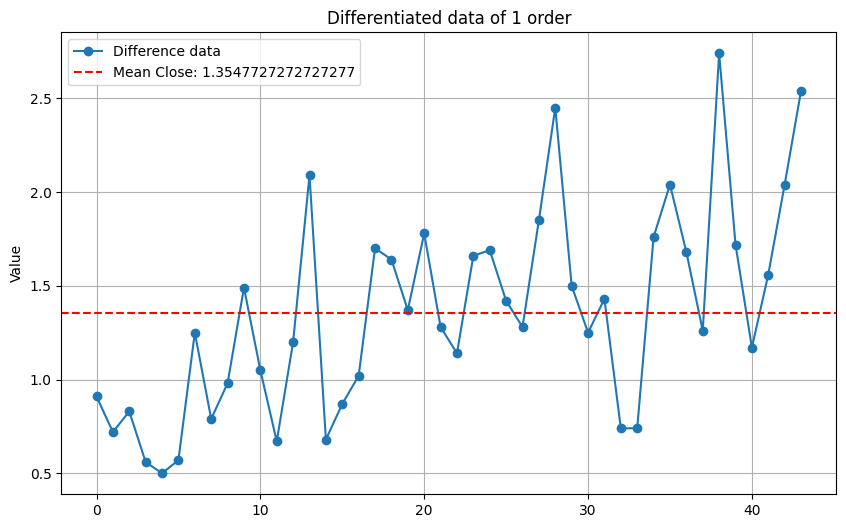

In [196]:
import numpy as np
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

# Differencing
def diff_and_ADF(df, n=1):
    diff_data = np.diff(df['Average CO2 Concentration (ppmv)'], n)

    # Проверка стационарности после дифференцирования
    ADF_result = adfuller(diff_data)
    print(f'ADF Statistic: {ADF_result[0]}')
    print(f'p-value: {ADF_result[1]}')

    mean_close = diff_data.mean()

    plt.figure(figsize=(10, 6))
    plt.plot(diff_data, marker='o', linestyle='-', label='Difference data')
    plt.axhline(mean_close, color='red', linestyle='--', label=f'Mean Close: {mean_close}')
    plt.title(f'Differentiated data of {n} order')
    plt.ylabel('Value')
    plt.grid(True)
    plt.legend()

    print('The series is now stationary!')
    if ADF_result[1] < 0.05 and ADF_result[0] < -3:
        print('We can reject the null hypothesis (the series is stationary)!')
        return diff_data


diff_data = diff_and_ADF(df)
print(diff_data.shape)

In [197]:
print(3.536616925667341e-21<0.000000001)

True


Well, This gives an ADF statistic of -9.4250983517889 and a p-value very
small. So, the new series is stationary.

In [198]:
print(diff_data.shape)

(44,)


#D) Separate your series into a train set and a test set.

In [199]:
from sklearn.model_selection import train_test_split

train = diff_data[:35]
test = diff_data[35:]

#print(X)

#E) Define a range of values for p and q, and generate combinations of orders (p, q).


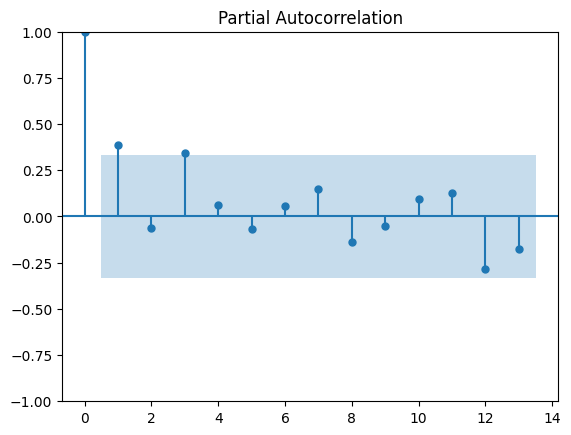

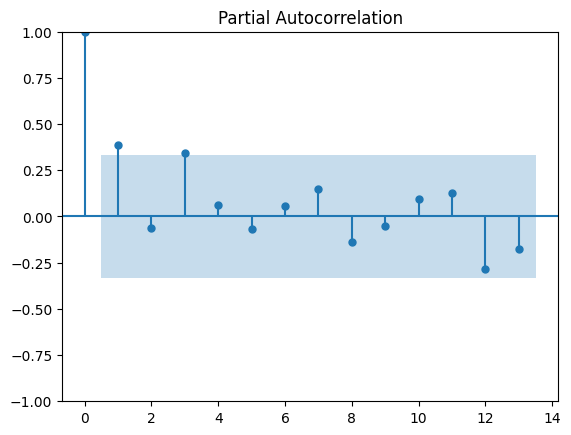

In [200]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(train, lags=13)

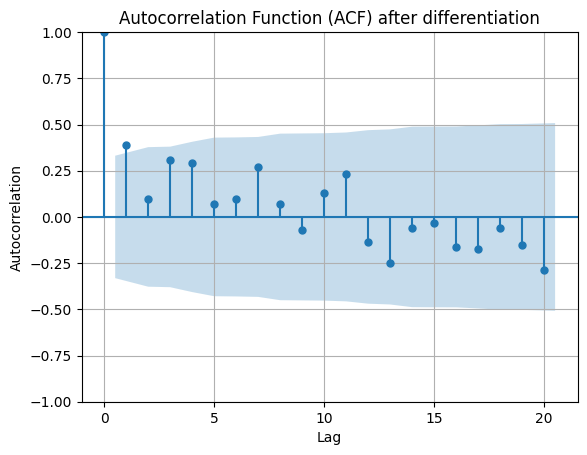

In [201]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(train, lags=20)
plt.title('Autocorrelation Function (ACF) after differentiation')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.show()


# From ACF and PACF we can + - we can consider the sequential measurement of q and p - we will consider p - [1,3] and for q - [1,2], p and q will not be 0, because from the graphical data it is clear that the data here is not AR or MA

In [202]:
p=[i for i in range(1,4)]
q=[i for i in range(1,4)]

p_and_q_combinations=[[i,j] for i in p for j in q]
print(p_and_q_combinations)

[[1, 1], [1, 2], [1, 3], [2, 1], [2, 2], [2, 3], [3, 1], [3, 2], [3, 3]]


In [203]:
p_second=[i for i in range(0,10)]
q_second=[i for i in range(0,7)]

p_and_q_combinations_second=[[i,j] for i in p_second for j in q_second]
print(p_and_q_combinations_second)

[[0, 0], [0, 1], [0, 2], [0, 3], [0, 4], [0, 5], [0, 6], [1, 0], [1, 1], [1, 2], [1, 3], [1, 4], [1, 5], [1, 6], [2, 0], [2, 1], [2, 2], [2, 3], [2, 4], [2, 5], [2, 6], [3, 0], [3, 1], [3, 2], [3, 3], [3, 4], [3, 5], [3, 6], [4, 0], [4, 1], [4, 2], [4, 3], [4, 4], [4, 5], [4, 6], [5, 0], [5, 1], [5, 2], [5, 3], [5, 4], [5, 5], [5, 6], [6, 0], [6, 1], [6, 2], [6, 3], [6, 4], [6, 5], [6, 6], [7, 0], [7, 1], [7, 2], [7, 3], [7, 4], [7, 5], [7, 6], [8, 0], [8, 1], [8, 2], [8, 3], [8, 4], [8, 5], [8, 6], [9, 0], [9, 1], [9, 2], [9, 3], [9, 4], [9, 5], [9, 6]]


#F) Fit all unique ARMA(p, q) models, and select the one with the lowest AIC.





In [204]:
from typing import Union
from tqdm import tqdm_notebook
from statsmodels.tsa.statespace.sarimax import SARIMAX

def optimize_ARMA(endog: Union[pd.Series, list], order_list: list) -> pd.DataFrame:
    results = []
    for order in tqdm_notebook(order_list):
      try:
        #ARIMA(p,0,q)=ARMA(p,q)
        model = SARIMAX(endog, order=(order[0], 0, order[1]),
        simple_differencing=False).fit(disp=False)
      except:
        continue
      aic = model.aic
      results.append([order, aic])
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q)', 'AIC']
    #Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC',
    ascending=True).reset_index(drop=True)
    return result_df

In [205]:
ARMA_statistic=optimize_ARMA(test, p_and_q_combinations)

<ipython-input-204-32f4296cfb88>:7: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for order in tqdm_notebook(order_list):


  0%|          | 0/9 [00:00<?, ?it/s]

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/p

In [206]:
print(ARMA_statistic)

    (p,q)        AIC
0  [1, 1]  24.937570
1  [1, 2]  26.932539
2  [2, 1]  26.935233
3  [1, 3]  26.983166
4  [3, 1]  27.117403
5  [2, 3]  28.164290
6  [2, 2]  28.171768
7  [3, 2]  29.670190
8  [3, 3]  31.688321


In [207]:
best_params = ARMA_statistic.loc[ARMA_statistic['AIC'].idxmin(), '(p,q)']
print(best_params)

[1, 1]


##We see that the best combination is p=1 and q=1

##I'll try to make the range a little larger and find the optimal combination of p and q on it

In [208]:
ARMA_statistic_second=optimize_ARMA(test, p_and_q_combinations_second)

<ipython-input-204-32f4296cfb88>:7: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for order in tqdm_notebook(order_list):


  0%|          | 0/70 [00:00<?, ?it/s]

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.10/dist-pa

In [209]:
print(ARMA_statistic_second)

     (p,q)        AIC
0   [8, 0]  21.405200
1   [8, 1]  23.517525
2   [9, 0]  23.555952
3   [7, 2]  23.659231
4   [7, 3]  24.204105
..     ...        ...
65  [6, 6]  35.037840
66  [0, 5]  35.177170
67  [4, 6]  35.827871
68  [0, 6]  36.818624
69  [0, 0]  39.357226

[70 rows x 2 columns]


In [210]:
best_params_second = ARMA_statistic.loc[ARMA_statistic_second['AIC'].idxmin(), '(p,q)']
print(best_params_second)


[1, 1]


We see that even in the extended range p=1 and q=1 is optimal. Conclusion: the initial assumptions based on the graphs turned out to be correct.

#G) Select the best model according to the AIC, and store the residuals in a variable.

In [211]:
best_model=SARIMAX(train, order=(1, 0, 1),
        simple_differencing=False).fit(disp=False)
residuals=best_model.resid
print(residuals)

[ 0.91       -0.09321628  0.06632559 -0.22407177 -0.21201125 -0.07989527
  0.62412859  0.00820593  0.19982265  0.6639945   0.06433369 -0.32683555
  0.28794604  1.11172521 -0.56572774 -0.23148885 -0.01970091  0.66999677
  0.45098673  0.07628426  0.4737021  -0.13600139 -0.23609941  0.34809193
  0.29913114 -0.03748673 -0.16147976  0.45477171  0.95011608 -0.22517334
 -0.41201563 -0.1234664  -0.77598464 -0.57912062  0.58868094]


#H) Perform a qualitative analysis of the residuals with the plot_diagnostics method. Does the Q-Q plot show a straight line that lies on y = x?


<function matplotlib.pyplot.tight_layout(*, pad=1.08, h_pad=None, w_pad=None, rect=None)>

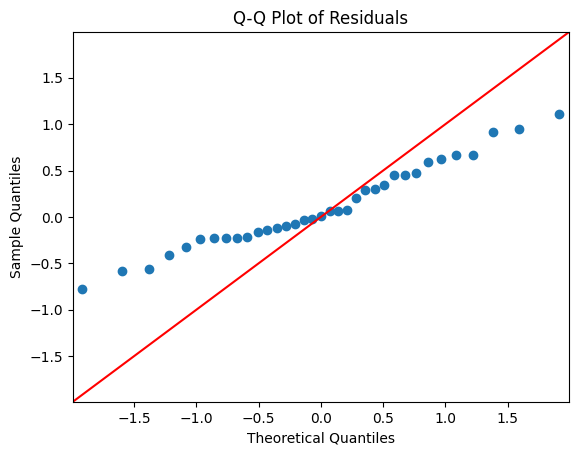

In [212]:
from statsmodels.graphics.gofplots import qqplot

qqplot(residuals, line='45')
plt.title('Q-Q Plot of Residuals')
plt.tight_layout

Does the Q-Q plot show a straight line that lies on y = x? -**NO**

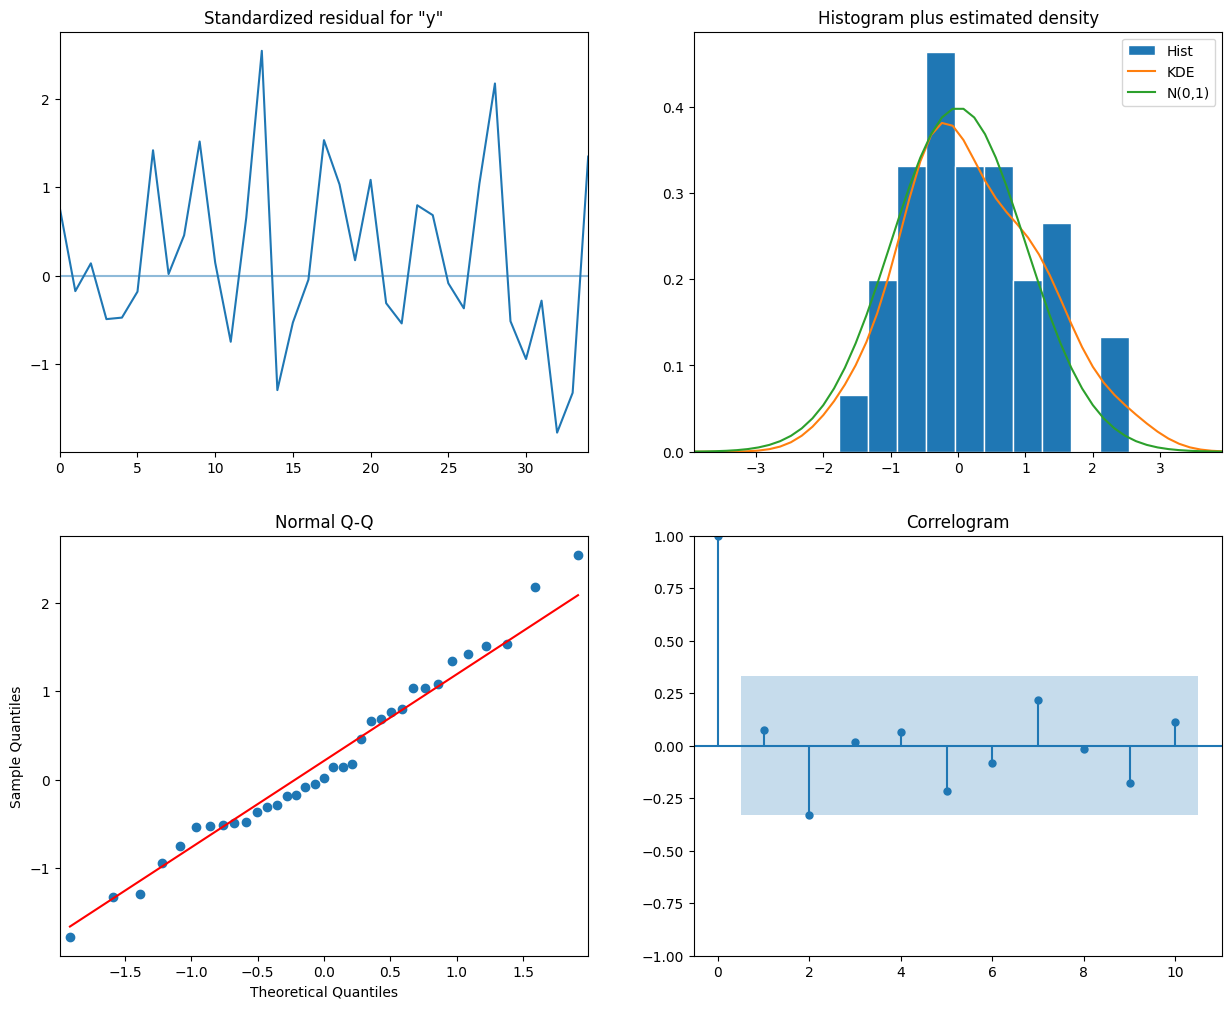

In [213]:
best_model.plot_diagnostics(figsize=(15, 12))
plt.show()

##**Conclusions**:
1)The model residuals correspond to a normal distribution. Because the residuals are normally distributed, the points on the graph lie on the straight line y = x.

2)Residuals are autocorrelated.

3)Residues are randomly distributed with no apparent patterns.

4)Using the Density Plot, we look at the distribution of residuals. It is close to a normal distribution.

#I) Perform a quantitative analysis of the residuals by applying the Ljung-Box test on the first 10 lags. Are all returned p-values above 0.05? Are the residuals correlated or not?

In [214]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box_test = acorr_ljungbox(residuals, lags=10, return_df=True)
print(ljung_box_test)

# Проверка, все ли p-значения выше 0.05
all_p_values_above_005 = all(ljung_box_test['lb_pvalue'] > 0.05)
print("Are all p-values above 0.05? ", all_p_values_above_005)


# коррелируют ли остатки?
if all_p_values_above_005:
    print("The residuals are not correlated.")
else:
    print("The residuals are correlated.")

     lb_stat  lb_pvalue
1   0.108975   0.741314
2   3.704306   0.156899
3   3.708654   0.294691
4   3.752276   0.440568
5   5.786939   0.327506
6   5.846223   0.440635
7   7.508109   0.377956
8   7.513943   0.482327
9   8.235258   0.510623
10  8.746820   0.556288
Are all p-values above 0.05?  True
The residuals are not correlated.


##Conclusion: all p-values ​​are above 0.05 and residuals are not correlated

#J) Make predictions using the selected ARMA(p, q) model, the mean method, and the last known value method.

In [215]:
def rolling_forecast(df: np.ndarray, train_len: int, horizon: int, window: int, method: str, p: int, q: int) -> list:
    total_len = train_len + horizon
    pred_values = []
    if method == 'mean':
        pred_mean = []
        for i in range(train_len, total_len, window):
            mean = np.mean(df[:i])
            pred_mean.extend(mean for _ in range(window))
        return pred_mean

    elif method == 'last':
        pred_last_value = []
        for i in range(train_len, total_len, window):
            last_value = df[i-1]  # Getting the last value in the slice
            pred_last_value.extend(last_value for _ in range(window))
        return pred_last_value

    elif method == 'ARMA':
        pred_ARMA = []
        for i in range(train_len, total_len, window):
            model = SARIMAX(df[:i], order=(p, 0, q))
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            pred = predictions.predicted_mean[-window:]  # Использование среза NumPy
            pred_ARMA.extend(pred)
        return pred_ARMA

    return pred_values


In [216]:
horizon = 9 # Горизонт прогнозирования
window = 2  # Длина окна
train_len=len(train)


pred_values_mean = rolling_forecast(diff_data, len(train), horizon, window, 'mean',p=1,q=1)
pred_values_last = rolling_forecast(diff_data, len(train), horizon, window, 'last',p=1,q=1)
pred_values_ARMA = rolling_forecast(diff_data, len(train), horizon, window, 'ARMA',p=1,q=1)


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


In [217]:

print(len(pred_values_mean))
print(len(pred_values_last))
print(len(pred_values_ARMA))

10
10
10


#K) Plot your forecasts.


In [218]:
print(len(test))

9


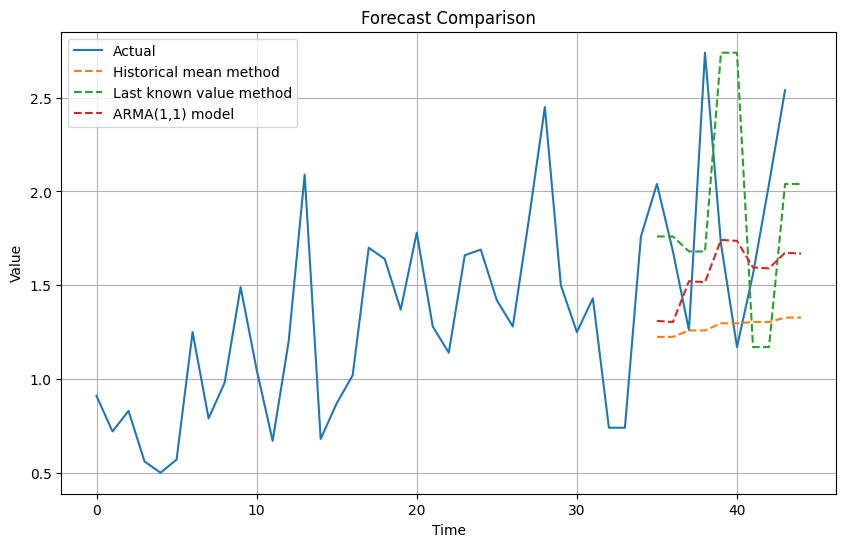

In [219]:


plt.figure(figsize=(10, 6))
plt.plot(diff_data, label='Actual')

#Historical mean method
plt.plot(np.arange(len(train), len(train) + len(test)+1),pred_values_mean, label='Historical mean method', linestyle='--')

#Last known value method
plt.plot(np.arange(len(train), len(train) + len(test)+1),pred_values_last, label='Last known value method', linestyle='--')

#ARMA(1,1) model
plt.plot(np.arange(len(train), len(train) + len(test)+1),pred_values_ARMA, label='ARMA(1,1) model', linestyle='--')

plt.title('Forecast Comparison')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

#L) Evaluate each method’s performance using the MSE. Which method performed best?


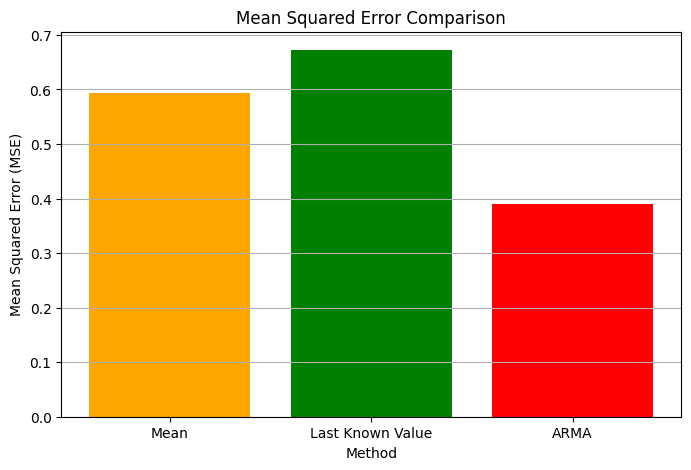

In [220]:
pred_df = pd.DataFrame()
pred_df['pred_mean'] = pred_values_mean[:9]
pred_df['pred_last_value'] = pred_values_last[:9]
pred_df['pred_ARMA'] =pred_values_ARMA[:9]


from sklearn.metrics import mean_squared_error

mse_mean =mean_squared_error(test,pred_df['pred_mean'])
mse_last = mean_squared_error(test,pred_df['pred_last_value'])
mse_ARMA = mean_squared_error(test,pred_df['pred_ARMA'])



# Список методов
methods = ['Mean', 'Last Known Value', 'ARMA']

# Список среднеквадратичных ошибок
mse_values = [mse_mean, mse_last, mse_ARMA]


plt.figure(figsize=(8, 5))
plt.bar(methods, mse_values, color=['orange', 'green', 'red'])
plt.xlabel('Method')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Mean Squared Error Comparison')
plt.grid(axis='y')
plt.show()

In [221]:
print(mse_values)

[0.5932053115864284, 0.6721222222222105, 0.39071567947852387]


##Best method performed: ARMA.

#M) Reverse differencing, plot the best forecast and calculate the MAE.

In [243]:
result_df= pd.DataFrame()


value_1993 = df.loc[df['Year'] == 1993, 'Average CO2 Concentration (ppmv)'].values[0]
index_1993 = df[df['Year'] == 1993].index[0]
value_1993 = df.iloc[index_1993]['Average CO2 Concentration (ppmv)']


df['result'] = pd.Series()
train_np=np.array(train)
#print(train)
#print(len(train))
df['result'][:35]=df['Average CO2 Concentration (ppmv)'][:35]

#print(df['result'])
df['result'][35:] = value_1993 + np.array(pred_values_ARMA).cumsum()

print(df['result'])

0          316.0
1         316.91
2         317.63
3         318.46
4         319.02
5         319.52
6         320.09
7         321.34
8         322.13
9         323.11
10         324.6
11        325.65
12        326.32
13        327.52
14        329.61
15        330.29
16        331.16
17        332.18
18        333.88
19        335.52
20        336.89
21        338.67
22        339.95
23        341.09
24        342.75
25        344.44
26        345.86
27        347.14
28        348.99
29        351.44
30        352.94
31        354.19
32        355.62
33        356.36
34         357.1
35     358.40977
36    359.713393
37    361.234899
38    362.751254
39    364.493094
40    366.229399
41    367.823961
42    369.413974
43    371.087376
44    372.756438
Name: result, dtype: object


<ipython-input-243-df0c10e39a43>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['result'][:35]=df['Average CO2 Concentration (ppmv)'][:35]
<ipython-input-243-df0c10e39a43>:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['result'][35:] = value_1993 + np.array(pred_values_ARMA).cumsum()


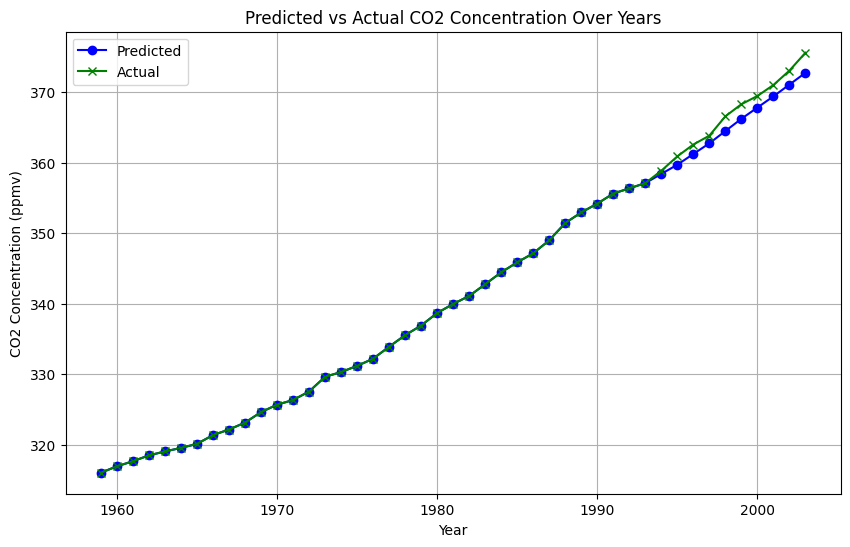

In [244]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))


plt.plot(df['Year'], df['result'], label='Predicted', color='blue', marker='o')


plt.plot(df['Year'], df['Average CO2 Concentration (ppmv)'], label='Actual', color='green', marker='x')

plt.title('Predicted vs Actual CO2 Concentration Over Years')
plt.xlabel('Year')
plt.ylabel('CO2 Concentration (ppmv)')
plt.legend()
plt.grid(True)

plt.show()


In [245]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(df['Average CO2 Concentration (ppmv)'], df['result'])

print("MAE:", mae)


MAE: 0.3628098180466143
